In [2]:
# ==============================================
# SPOTIFY ANALYSIS
# ==============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------Skill 1: Load Data---------------
spotify = pd.read_csv('/content/SpotifyFeatures.csv')

# ---------------Skill 2: Check Data-----------------
print(spotify.info())
print(spotify.head())
print(spotify.describe())

# ---------------Skill 3: Find Missing------------------
print(spotify.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [3]:
# ---------------Skill 4-5: Clean Data-------------------
# Fill Missing Values
spotify['track_name'].fillna('Unkown' , inplace=True)
spotify['artist_name'].fillna('Unknown' , inplace=True)

# Drop songs with missing audio features
spotify.dropna(subset=['popularity' , 'energy' , 'danceability'] , inplace=True)

/tmp/ipykernel_1386/492721947.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spotify['track_name'].fillna('Unkown' , inplace=True)
/tmp/ipykernel_1386/492721947.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [4]:
# ----------- SKILL 6: CONVERT DATES -----------
# If you have release date column:
# spotify['release_date'] = pd.to_datetime(spotify['release_date'])


In [6]:
# ------------------SKill 7: Extract from text----------------
# Extract first artist if multiple
spotify['main_artist'] = spotify['artist_name'].str.split(',').str[0]

In [8]:
# ---------------Skill 8: Count Values-------------------
print(spotify['main_artist'].value_counts().head(10))
print(spotify['genre'].value_counts().head(10))

main_artist
Giuseppe Verdi             1394
Giacomo Puccini            1137
Kimbo Children's Music      971
Nobuo Uematsu               825
Richard Wagner              804
Wolfgang Amadeus Mozart     800
Randy Newman                757
Georges Bizet               701
Juice Music                 684
Johann Sebastian Bach       632
Name: count, dtype: int64
genre
Comedy              9681
Soundtrack          9646
Indie               9543
Jazz                9441
Pop                 9386
Electronic          9377
Children’s Music    9353
Folk                9299
Hip-Hop             9295
Rock                9272
Name: count, dtype: int64


In [12]:
# --------------Skill 9: Filter Data------------------
popular_songs = spotify[spotify['popularity']>80]
print(f"Popular songs: {len([popular_songs])}")

energetic_songs = spotify[spotify['energy']>0.8]
print(f"Energetic songs: {len(energetic_songs)}")

# --------------Skill 10: GROUP DATA--------------------
# Average popularity by genre
popularity_by_genre = spotify.groupby('genre')['popularity'].mean().sort_values(ascending=False)
print("Most popular genres:")
print(popularity_by_genre.head(10))

Popular songs: 1
Energetic songs: 53949
Most popular genres:
genre
Pop                 66.590667
Rap                 60.533795
Rock                59.619392
Hip-Hop             58.423131
Dance               57.275256
Indie               54.701561
Children’s Music    54.659040
R&B                 52.308719
Alternative         50.213430
Folk                49.940209
Name: popularity, dtype: float64


In [15]:
# ----------------Skill 11: Create New Columns------------------
# Danceability category
def dance_category(score):
  if score < 0.3:
    return 'low'
  elif score < 0.6:
    return 'medium'
  else:
    return 'high'

spotify['DanceCategory'] = spotify['danceability'].apply(dance_category)

# Energy + Danceability combo
spotify['PartyScore'] = (spotify['energy'] + spotify['danceability']) / 2


0    medium
1    medium
2      high
3       low
4    medium
5    medium
6      high
7    medium
8      high
9    medium
Name: DanceCategory, dtype: object


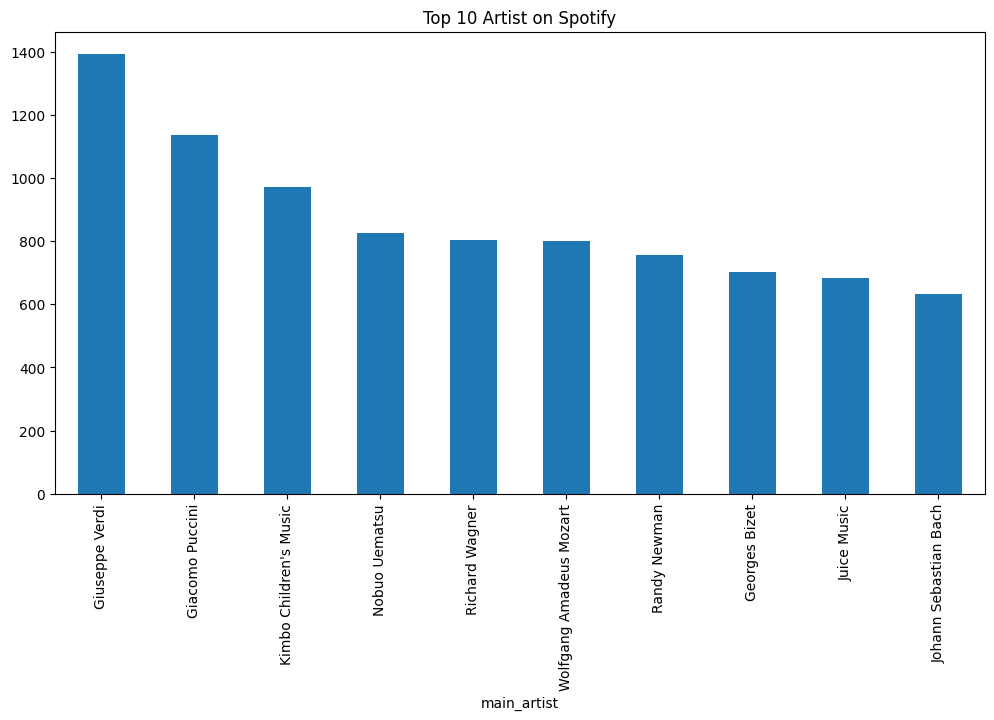

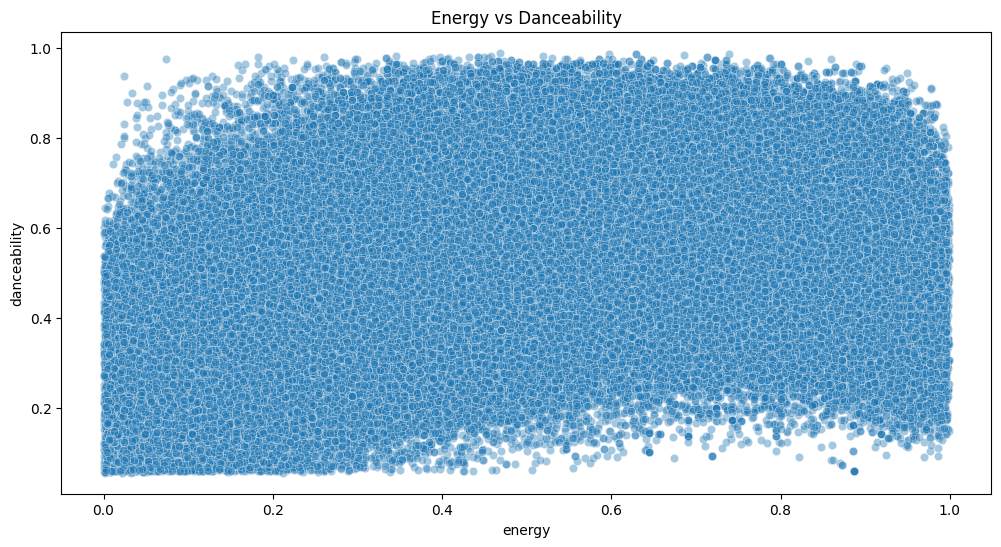

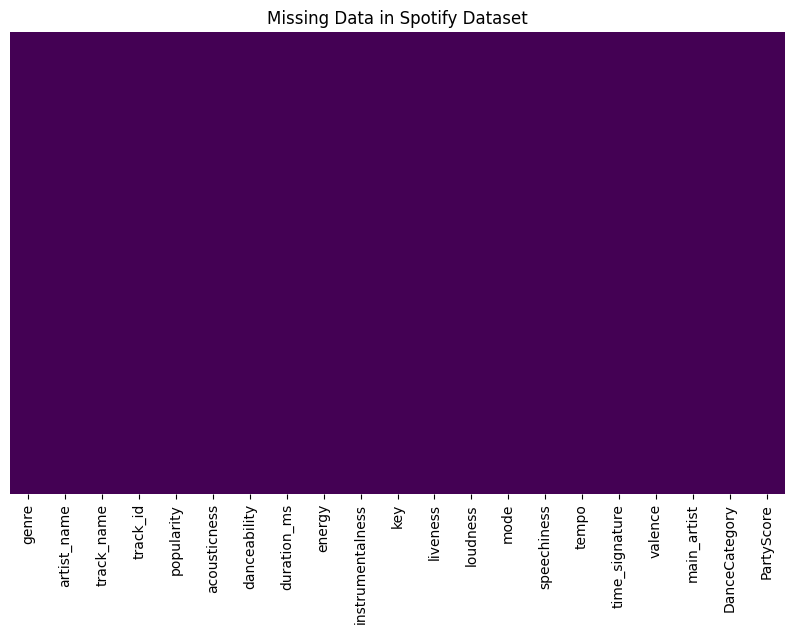

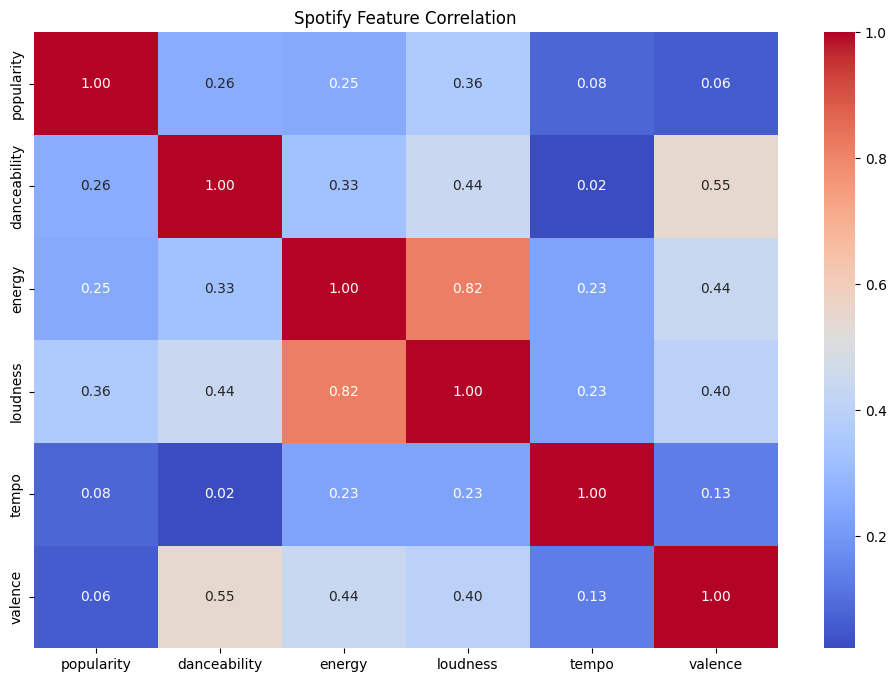

Spotify analysis complete


In [16]:
# -------------SKill 12-14: Visualize-----------------
# Bar chart - Top Artist
plt.figure(figsize=(12,6))
spotify['main_artist'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Artist on Spotify')
plt.savefig('spotify_artist.png')
plt.show()

# Scatter Plot - Energetic vs Danceabiltiy
plt.figure(figsize=(12,6))
sns.scatterplot(x='energy' , y= 'danceability' , data=spotify, alpha=0.4)
plt.title('Energy vs Danceability')
plt.savefig('spotify_energy_dance.png')
plt.show()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(spotify.isnull() , cbar=False , yticklabels=False, cmap='viridis')
plt.title('Missing Data in Spotify Dataset')
plt.savefig('spotify_missing.png')
plt.show()

# Feature Correlation
plt.figure(figsize=(12,8))
features = ['popularity' , 'danceability' , 'energy' , 'loudness' , 'tempo' , 'valence']
correlation = spotify[features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spotify Feature Correlation')
plt.savefig('spotify_correlation.png')
plt.show()

# SAVE

spotify.to_csv('spotify_cleaned.csv' , index=False)
print("Spotify analysis complete")